## 프로젝트 개요

**목표**: 서울의 실제 날씨 데이터를 API로 수집하고, Oracle DB의 배달 주문 데이터와 결합해서
"비 오는 날엔 어떤 메뉴가 더 잘 팔리는지" 분석하고, 그 결과를 Gradio 화면으로 출력

## 필수 스킬

| 단계 | 사용 기술 | 포인트 |
|---|---|---|
| 1. 날씨 데이터 수집 | `requests`로 외부 API 호출 (Open-Meteo, 무료·키 불필요) | **신규** — API 크롤링 |
| 2. 배달 주문 데이터 조회 | Oracle DB 연결 (`.env` + `with` 구문) | Chapter02 ex01 |
| 3. 데이터 결합 | `pd.merge()`, `groupby()`, `pivot_table()` | Chapter01, Chapter02 ex09 |
| 4. 통계 분석 | `numpy`로 상관관계, 그룹별 평균 비교 | Chapter02 ex02, ex10 |
| 5. 파일 저장 | `to_csv()`로 중간/최종 결과 저장 | 신규 (파일 저장 습관) |
| 6. 시각화 | `matplotlib` + `seaborn` (색상/라벨 커스터마이징) | Chapter02 ex03~06 |
| 7. 화면 구성 | `gr.Blocks` + 커스텀 테마/CSS | Chapter03 ex08, ex10 |

### 사전 준비
- Chapter02의 `.env`, `DELIVERY_ORDERS` 테이블이 그대로 필요
- 추가 설치: `uv pip install requests`

## Part 1. 라이브러리 및 환경 설정

In [21]:
import os
from dotenv import load_dotenv
import oracledb
import pandas as pd
import numpy as np
import requests
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import gradio as gr



# ─────────────────────────────────────────────────────────
# 차트 디자인 공통 설정
#   - seaborn의 "whitegrid" 테마로 배경을 깔끔하게
#   - font_scale로 전체적인 글자 크기를 살짝 키움
# ─────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", font_scale=1.05)

mpl.rc('font', family='AppleGothic')  # Mac은 'AppleGothic'
mpl.rc('axes', unicode_minus=False)

# 카테고리마다 고정된 색을 지정해두면, 어떤 그래프에서도
# "치킨은 항상 주황색"처럼 색이 일관돼서 보기 편합니다.
CATEGORY_COLORS = {
    "분식": "#FF6B6B",
    "치킨": "#FFA94D",
    "피자": "#FFD43B",
    "중식": "#69DB7C",
    "일식": "#4DABF7",
}

load_dotenv()
USER = os.getenv("ORACLE_USER")
PASSWORD = os.getenv("ORACLE_PASSWORD")
DSN = os.getenv("ORACLE_DSN")

SAVE_DIR = "data"
os.makedirs(SAVE_DIR, exist_ok=True)
print(f"'{SAVE_DIR}' 폴더 준비 완료")

'data' 폴더 준비 완료


## Part 2. Oracle DB에서 배달 주문 데이터 조회 (Chapter02 복습)

`.env` + `with` 구문 패턴을 그대로 재사용합니다.
`insert_extra_for_chart.sql`을 먼저 실행해두셔야 데이터가 충분합니다.

In [22]:
with oracledb.connect(user=USER, password=PASSWORD, dsn=DSN) as conn:
    orders_df = pd.read_sql("SELECT * FROM DELIVERY_ORDERS", conn)
# with 블록을 벗어나는 순간 자동으로 연결이 닫힘

orders_df["ORDER_DATE"] = pd.to_datetime(orders_df["ORDER_DATE"])
print(f"전체 주문 데이터 : {len(orders_df)}건")
orders_df.head()

전체 주문 데이터 : 11025건


/var/folders/4j/qgl7j0hx7y33d7l5bjgf9h9h0000gn/T/ipykernel_72491/1157993578.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  orders_df = pd.read_sql("SELECT * FROM DELIVERY_ORDERS", conn)


,ORDER_ID,MENU_NAME,CATEGORY,PRICE,RATING,REGION,ORDER_DATE
0,349,치즈피자,피자,22300,3.8,송파구,2025-09-02
1,350,치즈피자,피자,21200,4.3,성동구,2025-09-02
2,351,불고기피자,피자,25400,4.4,서초구,2025-09-02
3,352,짬뽕,중식,8000,4.2,마포구,2025-09-02
4,353,짜장면,중식,8400,4.2,송파구,2025-09-02


In [23]:
start_date = orders_df["ORDER_DATE"].min().strftime("%Y-%m-%d")
end_date = orders_df["ORDER_DATE"].max().strftime("%Y-%m-%d")
print(f"주문 데이터 날짜 범위 : {start_date} ~ {end_date}")

# 참고: end_date가 오늘 이후라면 날씨 API에서 데이터를 가져올 수 없습니다.
# insert_extra_for_chart.sql은 오늘 날짜(9/02) 이내로 맞춰뒀습니다.

주문 데이터 날짜 범위 : 2025-08-27 ~ 2026-09-02


## Part 3. 날씨 API 크롤링 (신규 — Open-Meteo)

**Open-Meteo**는 회원가입/API 키 없이 무료로 쓸 수 있는 날씨 API입니다.
`/v1/archive` 엔드포인트로 과거 특정 기간의 날씨(기온, 강수량)를 가져올 수 있습니다.

In [24]:
SEOUL_LAT = 37.5665
SEOUL_LON = 126.9780

def fetch_seoul_weather(start, end):
    """
    Open-Meteo 히스토리컬 날씨 API를 호출해서
    지정된 기간의 서울 날씨(최고/최저기온, 강수량)를 DataFrame으로 반환하는 함수.
    """
    url = "https://archive-api.open-meteo.com/v1/archive"
    params = {
        "latitude": SEOUL_LAT,
        "longitude": SEOUL_LON,
        "start_date": start,
        "end_date": end,
        "daily": "temperature_2m_max,temperature_2m_min,precipitation_sum",
        "timezone": "Asia/Seoul",
    }

    response = requests.get(url, params=params)
    response.raise_for_status()
    data = response.json()

    weather_df = pd.DataFrame(data["daily"])
    weather_df.columns = ["ORDER_DATE", "최고기온", "최저기온", "강수량"]
    weather_df["ORDER_DATE"] = pd.to_datetime(weather_df["ORDER_DATE"])
    return weather_df


weather_df = fetch_seoul_weather(start_date, end_date)
print(f"날씨 데이터 {len(weather_df)}일치 수집 완료")
weather_df.head()

날씨 데이터 372일치 수집 완료


,ORDER_DATE,최고기온,최저기온,강수량
0,2025-08-27,30.4,22.2,0.0
1,2025-08-28,30.1,23.9,1.4
2,2025-08-29,30.6,23.8,31.5
3,2025-08-30,31.0,23.6,7.7
4,2025-08-31,29.8,24.1,7.1


In [25]:
weather_csv_path = os.path.join(SAVE_DIR, "weather_seoul.csv")
weather_df.to_csv(weather_csv_path, index=False, encoding="utf-8-sig")
print(f"날씨 데이터 저장 완료 : {weather_csv_path}")

날씨 데이터 저장 완료 : data/weather_seoul.csv


## Part 4. 주문 데이터 + 날씨 데이터 결합 (Chapter01/02 복습)

In [26]:
daily_category = (
    orders_df.groupby(["ORDER_DATE", "CATEGORY"])
    .size()
    .reset_index(name="주문건수")
)
merged_df = pd.merge(daily_category, weather_df, on="ORDER_DATE", how="left")
merged_df["날씨구분"] = np.where(merged_df["강수량"] > 0, "비", "맑음")

print(f"결합된 데이터 : {len(merged_df)}행")
merged_df.head(10)

결합된 데이터 : 1807행


,ORDER_DATE,CATEGORY,주문건수,최고기온,최저기온,강수량,날씨구분
0,2025-08-27,분식,9,30.4,22.2,0.0,맑음
1,2025-08-27,일식,8,30.4,22.2,0.0,맑음
2,2025-08-27,중식,4,30.4,22.2,0.0,맑음
3,2025-08-27,치킨,7,30.4,22.2,0.0,맑음
4,2025-08-27,피자,1,30.4,22.2,0.0,맑음
5,2025-08-28,분식,12,30.1,23.9,1.4,비
6,2025-08-28,일식,1,30.1,23.9,1.4,비
7,2025-08-28,중식,6,30.1,23.9,1.4,비
8,2025-08-28,치킨,7,30.1,23.9,1.4,비
9,2025-08-28,피자,3,30.1,23.9,1.4,비


## Part 5. numpy 분석 + 시각화 (Chapter02 복습, 디자인 강화)

카테고리별 고정 색상, 막대 위 숫자 라벨, 큰 제목 폰트를 적용해서
그래프가 한눈에 잘 읽히도록 꾸몄습니다.

In [27]:
weather_category_pivot = pd.pivot_table(
    merged_df, values="주문건수", index="CATEGORY", columns="날씨구분",
    aggfunc="mean", fill_value=0,
).round(2)
weather_category_pivot["증감량(비-맑음)"] = (
    weather_category_pivot["비"] - weather_category_pivot["맑음"]
)
weather_category_pivot_sorted = weather_category_pivot.sort_values("증감량(비-맑음)", ascending=False)

print("=== 비 오는 날 주문이 더 느는 카테고리 순위 ===")
print(weather_category_pivot_sorted)

=== 비 오는 날 주문이 더 느는 카테고리 순위 ===
날씨구분        맑음      비  증감량(비-맑음)
CATEGORY                        
분식        6.28  11.53       5.25
치킨        5.19   9.92       4.73
피자        3.82   6.23       2.41
중식        4.06   6.08       2.02
일식        3.36   3.66       0.30


findfont: Failed to find font weight bold, now using 400.
findfont: Failed to find font weight bold, now using 400.


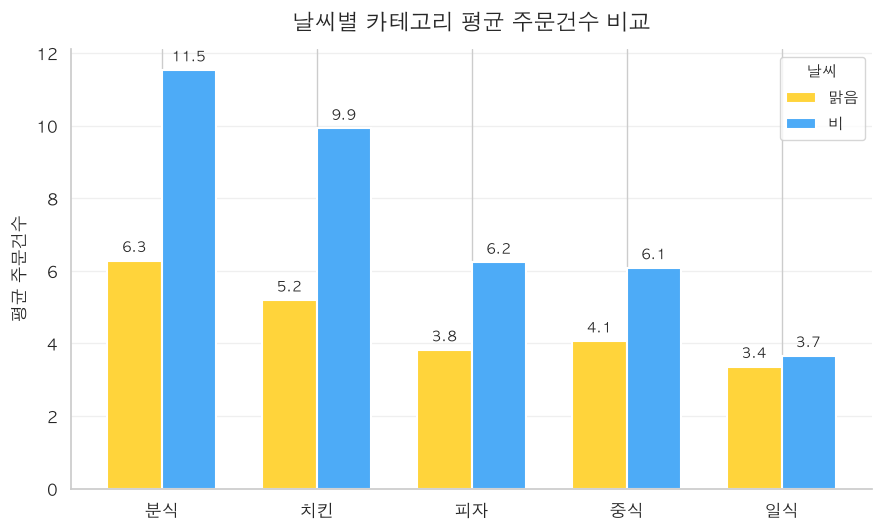

In [28]:
# ─────────────────────────────────────────────────────────
# 시각화 1 : 카테고리별 "맑음 vs 비" 평균 주문건수 (색상 + 숫자 라벨)
# ─────────────────────────────────────────────────────────
categories_order = weather_category_pivot_sorted.index.tolist()
sunny_values = weather_category_pivot_sorted["맑음"].values
rainy_values = weather_category_pivot_sorted["비"].values

x = np.arange(len(categories_order))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5.5))
bars1 = ax.bar(x - width/2, sunny_values, width, label="맑음",
               color="#FFD43B", edgecolor="white", linewidth=1.5)
bars2 = ax.bar(x + width/2, rainy_values, width, label="비",
               color="#4DABF7", edgecolor="white", linewidth=1.5)

# 막대 위에 정확한 값을 숫자로 표시 (bar_label)
ax.bar_label(bars1, padding=3, fontsize=10, fontweight="bold", fmt="%.1f")
ax.bar_label(bars2, padding=3, fontsize=10, fontweight="bold", fmt="%.1f")

ax.set_title("날씨별 카테고리 평균 주문건수 비교", fontsize=16, fontweight="bold", pad=14)
ax.set_ylabel("평균 주문건수", fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(categories_order, fontsize=12)
ax.legend(title="날씨", fontsize=11, title_fontsize=11, frameon=True)
sns.despine(left=False, bottom=False)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

findfont: Failed to find font weight bold, now using 400.


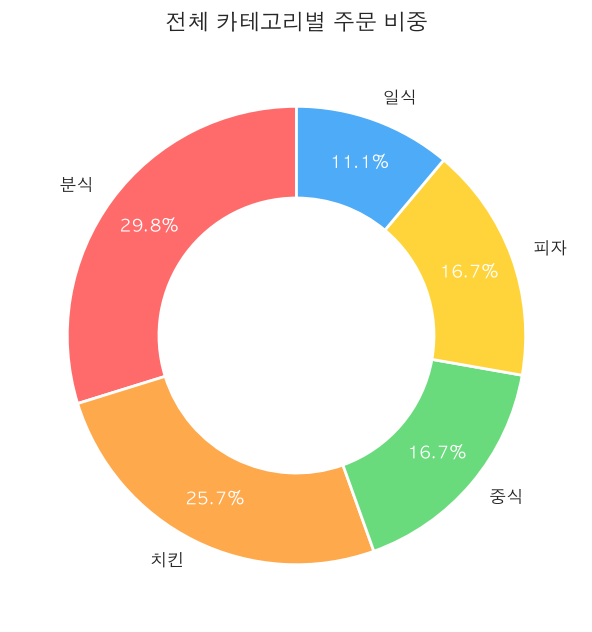

In [29]:
# ─────────────────────────────────────────────────────────
# 시각화 2 : 카테고리별 전체 주문 비중 (도넛 차트 - 카테고리 고정색 적용)
# ─────────────────────────────────────────────────────────
category_totals = orders_df["CATEGORY"].value_counts()
colors = [CATEGORY_COLORS.get(cat, "#ADB5BD") for cat in category_totals.index]

fig, ax = plt.subplots(figsize=(6.5, 6.5))
wedges, texts, autotexts = ax.pie(
    category_totals.values,
    labels=category_totals.index,
    colors=colors,
    autopct="%1.1f%%",
    startangle=90,
    pctdistance=0.8,
    textprops={"fontsize": 12, "fontweight": "bold"},
    wedgeprops={"width": 0.4, "edgecolor": "white", "linewidth": 2},  # 도넛 모양
)
for autotext in autotexts:
    autotext.set_color("white")

ax.set_title("전체 카테고리별 주문 비중", fontsize=16, fontweight="bold", pad=14)
plt.tight_layout()
plt.show()

In [30]:
# 강수량과 총 주문건수의 상관계수 (Chapter02 ex02 복습)
daily_total = merged_df.groupby("ORDER_DATE").agg(
    총주문건수=("주문건수", "sum"),
    강수량=("강수량", "first"),
).reset_index()

corr_matrix = np.corrcoef(daily_total["강수량"], daily_total["총주문건수"])
corr_value = corr_matrix[0, 1]
print(f"강수량-총주문건수 상관계수 : {corr_value:.3f}")

if corr_value > 0.3:
    print("-> 비가 많이 온 날일수록 전체 배달 주문이 늘어나는 경향이 있습니다.")
elif corr_value < -0.3:
    print("-> 비가 많이 온 날일수록 전체 배달 주문이 줄어드는 경향이 있습니다.")
else:
    print("-> 강수량과 전체 주문건수 사이에 뚜렷한 관계는 보이지 않습니다.")

강수량-총주문건수 상관계수 : 0.558
-> 비가 많이 온 날일수록 전체 배달 주문이 늘어나는 경향이 있습니다.


## Part 6. 분석 결과 파일 저장

In [31]:
merged_csv_path = os.path.join(SAVE_DIR, "merged_weather_orders.csv")
merged_df.to_csv(merged_csv_path, index=False, encoding="utf-8-sig")

summary_csv_path = os.path.join(SAVE_DIR, "weather_category_summary.csv")
weather_category_pivot_sorted.to_csv(summary_csv_path, encoding="utf-8-sig")

print(f"결합 데이터 저장 완료 : {merged_csv_path}")
print(f"요약 분석 저장 완료   : {summary_csv_path}")

결합 데이터 저장 완료 : data/merged_weather_orders.csv
요약 분석 저장 완료   : data/weather_category_summary.csv


## Part 7. Gradio 대시보드 (Chapter03 복습, 디자인 전면 개편)

이번엔 화면 자체를 꾸며봅니다.
- **테마**: `gr.themes.Soft`로 기본 제공 테마 중 부드러운 스타일 적용
- **커스텀 CSS**: 글자 크기, 카드 모서리, 그림자, 배너 등을 직접 지정
- **컬러 배너**: 상단에 그라데이션 배경의 타이틀 영역 추가

In [32]:
# ─────────────────────────────────────────────────────────
# 커스텀 CSS : 전체적으로 글자 크기를 키우고, 카드 모서리를 둥글게,
#              버튼과 입력창에 그림자를 넣어 화면을 화사하게 만듭니다.
# ─────────────────────────────────────────────────────────
custom_css = """
.gradio-container {
    font-size: 16px !important;
}
#title-banner {
    background: linear-gradient(135deg, #FF9A5A 0%, #FF6F91 50%, #4DABF7 100%);
    padding: 28px 24px;
    border-radius: 18px;
    text-align: center;
    margin-bottom: 20px;
    box-shadow: 0 8px 20px rgba(0,0,0,0.12);
}
#title-banner h1 {
    color: white !important;
    font-size: 30px !important;
    margin: 0 0 6px 0 !important;
}
#title-banner p {
    color: white !important;
    font-size: 15px !important;
    opacity: 0.95;
    margin: 0 !important;
}
.gr-button {
    font-size: 16px !important;
    font-weight: 600 !important;
    border-radius: 12px !important;
    padding: 10px 22px !important;
    box-shadow: 0 3px 8px rgba(0,0,0,0.15) !important;
}
label {
    font-size: 15px !important;
    font-weight: 600 !important;
}
.gr-box, .gr-panel, .gr-form {
    border-radius: 14px !important;
}
"""

# ─────────────────────────────────────────────────────────
# 테마 : Soft 테마 + 주황/파랑 계열 색상 지정
# ─────────────────────────────────────────────────────────
custom_theme = gr.themes.Soft(
    primary_hue="orange",
    secondary_hue="blue",
    radius_size="lg",
)

In [33]:
# 탭1 : 날짜별 상세 조회 함수
def show_daily_detail(selected_date):
    day_data = merged_df[merged_df["ORDER_DATE"] == pd.to_datetime(selected_date)]

    if len(day_data) == 0:
        return "해당 날짜의 데이터가 없습니다.", None

    weather_info = day_data.iloc[0]
    weather_emoji = "☔" if weather_info["날씨구분"] == "비" else "☀️"
    info_text = (
        f"📅 {selected_date}\n"
        f"🌡️ 최고 {weather_info['최고기온']:.1f}°C / 최저 {weather_info['최저기온']:.1f}°C\n"
        f"{weather_emoji} 강수량 {weather_info['강수량']:.1f}mm ({weather_info['날씨구분']})"
    )

    day_data_sorted = day_data.sort_values("주문건수", ascending=False)
    colors = [CATEGORY_COLORS.get(c, "#ADB5BD") for c in day_data_sorted["CATEGORY"]]

    fig, ax = plt.subplots(figsize=(6.5, 4.5))
    bars = ax.bar(day_data_sorted["CATEGORY"], day_data_sorted["주문건수"],
                   color=colors, edgecolor="white", linewidth=1.5)
    ax.bar_label(bars, padding=3, fontsize=11, fontweight="bold")
    ax.set_title(f"{selected_date} 카테고리별 주문 건수", fontsize=14, fontweight="bold")
    ax.set_ylabel("주문건수", fontsize=11)
    sns.despine()
    plt.tight_layout()

    return info_text, fig


# 탭2 : 비/맑음 비교 함수 (Part5 그래프 재사용)
def show_weather_comparison():
    x = np.arange(len(categories_order))
    width = 0.35

    fig, ax = plt.subplots(figsize=(8, 5))
    bars1 = ax.bar(x - width/2, sunny_values, width, label="맑음",
                   color="#FFD43B", edgecolor="white", linewidth=1.5)
    bars2 = ax.bar(x + width/2, rainy_values, width, label="비",
                   color="#4DABF7", edgecolor="white", linewidth=1.5)
    ax.bar_label(bars1, padding=3, fontsize=10, fontweight="bold", fmt="%.1f")
    ax.bar_label(bars2, padding=3, fontsize=10, fontweight="bold", fmt="%.1f")

    ax.set_title("날씨별 카테고리 평균 주문건수 비교", fontsize=15, fontweight="bold")
    ax.set_ylabel("평균 주문건수", fontsize=11)
    ax.set_xticks(x)
    ax.set_xticklabels(categories_order, fontsize=11)
    ax.legend(title="날씨")
    sns.despine()
    plt.tight_layout()
    return fig

In [34]:
available_dates = sorted(merged_df["ORDER_DATE"].dt.strftime("%Y-%m-%d").unique().tolist())

with gr.Blocks(title="날씨-배달 메뉴 수요 분석기") as demo:

    # 상단 그라데이션 배너
    gr.HTML(
        """
        <div id="title-banner">
            <h1>🌦️ 날씨-배달 메뉴 수요 분석기</h1>
            <p>Chapter01~03 종합 복습 프로젝트 · 날씨에 따라 어떤 메뉴가 잘 팔릴까요?</p>
        </div>
        """
    )

    with gr.Tab("📅 날짜별 상세 조회"):
        with gr.Row():
            date_dropdown = gr.Dropdown(available_dates, label="날짜 선택", scale=3)
            search_btn = gr.Button("🔍 조회하기", variant="primary", scale=1)
        with gr.Row():
            info_output = gr.Textbox(label="날씨 정보", lines=3)
            chart_output = gr.Plot(label="카테고리별 주문건수")

        search_btn.click(
            fn=show_daily_detail,
            inputs=date_dropdown,
            outputs=[info_output, chart_output],
        )

    with gr.Tab("☔ 비 vs ☀️ 맑음 비교"):
        gr.Markdown("### 날씨에 따라 카테고리별 평균 주문건수가 어떻게 달라지는지 비교해보세요.")
        compare_btn = gr.Button("📊 비교 그래프 보기", variant="primary")
        compare_output = gr.Plot(label="날씨별 카테고리 평균 주문건수")

        compare_btn.click(
            fn=show_weather_comparison,
            inputs=None,
            outputs=compare_output,
        )


# ⚠️ Gradio 6.0부터 theme/css는 gr.Blocks()가 아니라 launch()에 전달합니다.
demo.launch(theme=custom_theme, css=custom_css)

* Running on local URL:  http://127.0.0.1:7861
* To create a public link, set `share=True` in `launch()`.


In [35]:

# ⚠️ 실습 팁: 확인이 끝나면 데모를 꺼주는 습관을 들이세요.
# demo.close()


### 💡 디자인 개선 포인트 정리

| 개선 항목 | 적용 방법 |
|---|---|
| 카테고리별 색상 통일 | `CATEGORY_COLORS` 딕셔너리로 어느 그래프에서도 같은 카테고리는 같은 색 |
| 막대 위 숫자 표시 | `ax.bar_label()` — 색만 보고 짐작하지 않고 정확한 값도 함께 표시 |
| 그래프 여백/테두리 정리 | `sns.despine()` — 불필요한 위/오른쪽 테두리 제거 |
| 제목/라벨 폰트 키우기 | `fontsize`, `fontweight="bold"` 직접 지정 |
| Gradio 전체 테마 | `gr.themes.Soft(primary_hue=..., secondary_hue=...)` |
| Gradio 세부 스타일 | `css=custom_css`로 글자 크기, 버튼 그림자, 카드 모서리 직접 지정 |
| 상단 배너 | `gr.HTML()`로 그라데이션 배경의 타이틀 영역 추가 |
| 이모지 활용 | 탭 제목, 버튼, 텍스트에 이모지를 곁들여 화면을 화사하게 |

## 마무리 — 이 프로젝트에서 복습한 것 정리

| 배운 내용 | 이 프로젝트에서 사용한 곳 |
|---|---|
| pandas 기초 (Chapter01) | groupby, merge, 조건 필터링 전체 |
| Oracle DB 연동 (Chapter02) | `.env` + `with` 구문으로 안전하게 연결 |
| numpy 통계 (Chapter02) | 상관계수 계산 |
| matplotlib/seaborn (Chapter02) | 색상/라벨 커스터마이징까지 확장 |
| Gradio (Chapter03) | `gr.Blocks`, `gr.Tab`, 테마, 커스텀 CSS |
| **신규** | 외부 API 크롤링(requests), CSV 파일 저장 |

### 🎯 과제로 확장한다면 (학생들에게 던질 질문)
1. 날씨 항목에 "풍속"이나 "습도"를 추가해서 분석을 확장할 수 있을까?
2. 서울이 아니라 다른 지역(부산, 대구 등) 날씨와 비교하려면 코드를 어떻게 바꿔야 할까?
3. `CATEGORY_COLORS`에 없는 새 카테고리가 추가되면 색이 어떻게 나올까? (기본값 `"#ADB5BD"` 확인)
4. 지금은 CSV로 저장했는데, 이 결과를 Oracle DB에 새로운 테이블로 저장하려면 어떻게 해야 할까?

## 부록 A. 데이터 스케일업 — 랜덤 주문 데이터 대량 생성

지금 `DELIVERY_ORDERS`는 69건뿐이라 하루에 카테고리당 1~2건 수준입니다.
이 정도면 "평균 주문건수" 그래프가 거의 1.0 근처에서 평평하게 나오고,
상관계수도 의미 있는 값이 나오기 어렵습니다.

### 어떻게 만들어야 할까?

**그냥 완전 랜덤으로 넣으면 안 됩니다.**
`np.random.randint`로 아무 값이나 채워 넣으면 날씨와 주문 사이에 아무 관계도 없기 때문에,
Part 5의 상관계수는 0 근처로, 비/맑음 막대그래프는 똑같은 높이로 나옵니다.
분석 결과가 "아무 의미 없음"이 되어버리죠.

그래서 순서를 이렇게 잡습니다.

1. **날씨를 먼저 가져온다** (`fetch_seoul_weather`를 재사용)
2. 그 날의 **강수량·기온·요일**을 보고 카테고리별 "그날 몇 건 팔렸을지"를 정한다
3. 정해진 건수만큼 주문 행(메뉴/가격/평점/지역)을 만든다
4. `executemany`로 DB에 한 번에 INSERT 한다

이렇게 하면 "비 오는 날엔 치킨·분식이 잘 팔린다"는 패턴이 **데이터 안에 실제로 심어지고**,
Part 5의 분석이 그 패턴을 찾아내는 구조가 됩니다.

> ⚠️ 이 셀들은 **한 번만** 실행하세요. 여러 번 실행하면 데이터가 계속 누적됩니다.
> 실행 후에는 커널을 재시작하고 Part 1부터 다시 실행하면 늘어난 데이터로 분석이 됩니다.


In [36]:
# ─────────────────────────────────────────────────────────
# A-1. 생성 규칙 정의
# ─────────────────────────────────────────────────────────
from datetime import date, timedelta

# 시드를 고정하면 몇 번을 돌려도 "같은 랜덤 값"이 나옵니다.
# 실습에서 결과를 재현하려면 시드 고정이 필수입니다.
rng = np.random.default_rng(42)

# 생성 기간
#   Open-Meteo 아카이브 API는 보통 2~5일 정도 지연이 있어서
#   여유 있게 "오늘 - 7일"까지만 잡아두면 안전합니다.
GEN_END   = date.today() - timedelta(days=7)
GEN_START = GEN_END - timedelta(days=365)   # 1년치
print(f"생성 기간 : {GEN_START} ~ {GEN_END}")

# 카테고리별 메뉴 카탈로그 : (메뉴명, 기준가격)
MENU_CATALOG = {
    "분식": [("떡볶이", 9000), ("김밥", 5000), ("순대", 8000), ("라면", 6000), ("튀김", 7000)],
    "치킨": [("후라이드", 20000), ("양념치킨", 22000), ("간장치킨", 23000), ("치킨윙", 19000)],
    "피자": [("페퍼로니피자", 25000), ("불고기피자", 27000), ("치즈피자", 23000), ("고구마피자", 26000)],
    "중식": [("짜장면", 8000), ("짬뽕", 9000), ("탕수육", 18000), ("마라탕", 13000)],
    "일식": [("초밥", 20000), ("돈카츠", 12000), ("우동", 9000), ("규동", 11000)],
}

REGIONS        = ["강남구", "서초구", "송파구", "마포구", "용산구", "성동구", "노원구"]
REGION_WEIGHTS = [0.22, 0.16, 0.15, 0.13, 0.12, 0.12, 0.10]   # 합이 1이어야 함

# 카테고리별 "맑은 날 하루 평균 주문건수" (기준값)
BASE_ORDERS = {"분식": 6.0, "치킨": 5.0, "피자": 3.5, "중식": 4.0, "일식": 3.0}

# 카테고리별 "비 민감도"
#   1.0보다 크면 비 오는 날 주문이 늘고, 작으면 줄어듭니다.
#   -> 이 숫자가 곧 Part 5에서 우리가 "발견"하게 될 정답입니다.
RAIN_EFFECT = {"분식": 1.45, "치킨": 1.60, "피자": 1.35, "중식": 1.15, "일식": 0.85}


생성 기간 : 2025-08-27 ~ 2026-08-27


In [37]:
# ─────────────────────────────────────────────────────────
# A-2. 날씨를 먼저 받아온 뒤, 날씨에 맞춰 주문 행을 생성
# ─────────────────────────────────────────────────────────
gen_weather = fetch_seoul_weather(GEN_START.isoformat(), GEN_END.isoformat())
print(f"날씨 {len(gen_weather)}일치 확보")

rows = []   # DB에 넣을 (메뉴, 카테고리, 가격, 평점, 지역, 날짜) 튜플 리스트

for w in gen_weather.itertuples(index=False):
    order_date = w.ORDER_DATE.to_pydatetime()
    rain       = w.강수량
    is_rainy   = rain > 0

    # 주말에는 배달이 더 많다는 가정 (월=0 ... 토=5, 일=6)
    weekend_factor = 1.35 if order_date.weekday() >= 5 else 1.0
    # 더운 날엔 조금 더 시켜먹는다는 가정
    temp_factor = 1 + (w.최고기온 - 20) * 0.01

    for category, menu_list in MENU_CATALOG.items():
        lam = BASE_ORDERS[category] * weekend_factor * temp_factor

        if is_rainy:
            # 비가 많이 올수록 효과가 커지되, 최대 1.5배까지만
            rain_strength = min(1 + rain / 40, 1.5)
            lam *= RAIN_EFFECT[category] * rain_strength

        # 포아송 분포 : "하루에 몇 건"처럼 0 이상의 정수 개수를 뽑을 때 쓰는 분포.
        # 평균이 lam이고, 실제 값은 그 주변에서 자연스럽게 흔들립니다.
        n_orders = rng.poisson(max(lam, 0.1))

        for _ in range(n_orders):
            menu_name, base_price = menu_list[rng.integers(len(menu_list))]

            # 가격은 기준가 ±8% 정도로 흔들고 100원 단위로 반올림
            price = int(round(base_price * rng.normal(1.0, 0.08) / 100) * 100)

            # 평점은 4.3 근처에 몰리게, 1.0~5.0 범위로 자르고 소수 첫째자리까지
            rating = round(float(np.clip(rng.normal(4.3, 0.4), 1.0, 5.0)), 1)

            region = str(rng.choice(REGIONS, p=REGION_WEIGHTS))

            rows.append((menu_name, category, price, rating, region, order_date))

print(f"생성된 주문 행 : {len(rows):,}건")

# 눈으로 한 번 확인 (DB에 넣기 전에 미리보기 하는 습관!)
preview_df = pd.DataFrame(rows, columns=["MENU_NAME", "CATEGORY", "PRICE", "RATING", "REGION", "ORDER_DATE"])
preview_df.head(10)


날씨 366일치 확보
생성된 주문 행 : 10,956건


,MENU_NAME,CATEGORY,PRICE,RATING,REGION,ORDER_DATE
0,순대,분식,8500,4.3,성동구,2025-08-27
1,김밥,분식,5200,4.0,마포구,2025-08-27
2,튀김,분식,7500,4.3,용산구,2025-08-27
3,떡볶이,분식,8500,4.8,성동구,2025-08-27
4,라면,분식,5800,4.5,강남구,2025-08-27
5,라면,분식,6200,4.5,용산구,2025-08-27
6,김밥,분식,4800,4.0,송파구,2025-08-27
7,튀김,분식,7600,4.3,송파구,2025-08-27
8,김밥,분식,5300,4.6,성동구,2025-08-27
9,후라이드,치킨,21100,4.3,성동구,2025-08-27


In [38]:
# ─────────────────────────────────────────────────────────
# A-3. 생성한 데이터가 의도대로 만들어졌는지 검증
#      (DB에 넣기 전에 확인하는 게 훨씬 싸게 먹힙니다)
# ─────────────────────────────────────────────────────────
check = preview_df.groupby([preview_df["ORDER_DATE"], "CATEGORY"]).size().reset_index(name="주문건수")
check = pd.merge(check, gen_weather, on="ORDER_DATE", how="left")
check["날씨구분"] = np.where(check["강수량"] > 0, "비", "맑음")

check_pivot = pd.pivot_table(check, values="주문건수", index="CATEGORY",
                             columns="날씨구분", aggfunc="mean").round(2)
check_pivot["실제 증감률"] = (check_pivot["비"] / check_pivot["맑음"]).round(2)

# 기대 증감률 = RAIN_EFFECT × (비 온 날들의 평균 rain_strength)
#   A-2에서 강수량이 많을수록 효과를 더 키웠기 때문에,
#   RAIN_EFFECT 값 그 자체와 바로 비교하면 어긋나 보입니다.
rainy_days = gen_weather[gen_weather["강수량"] > 0]
mean_strength = np.minimum(1 + rainy_days["강수량"] / 40, 1.5).mean()
check_pivot["기대 증감률"] = (pd.Series(RAIN_EFFECT) * mean_strength).round(2)

print(f"비 온 날 {len(rainy_days)}일, 평균 강수 보정 계수 : {mean_strength:.2f}")
print("=== 의도한 값과 실제 생성 결과 비교 ===")
print(check_pivot)
print("\n'실제 증감률'이 '기대 증감률'보다 모든 카테고리에서 10% 정도 높게 나옵니다.")
print("서울은 비가 여름에 몰려 오는데, A-2에서 기온이 높으면 주문이 늘도록(temp_factor) 만들었기 때문입니다.")
print("즉 '비'와 '기온'이 함께 움직이는 교란 요인 → 실제 데이터 분석에서도 늘 조심해야 할 부분입니다.")


비 온 날 188일, 평균 강수 보정 계수 : 1.15
=== 의도한 값과 실제 생성 결과 비교 ===
날씨구분        맑음      비  실제 증감률  기대 증감률
CATEGORY                             
분식        6.28  11.43    1.82    1.66
일식        3.35   3.60    1.07    0.98
중식        4.05   6.04    1.49    1.32
치킨        5.18  10.11    1.95    1.84
피자        3.81   6.32    1.66    1.55

'실제 증감률'이 '기대 증감률'보다 모든 카테고리에서 10% 정도 높게 나옵니다.
서울은 비가 여름에 몰려 오는데, A-2에서 기온이 높으면 주문이 늘도록(temp_factor) 만들었기 때문입니다.
즉 '비'와 '기온'이 함께 움직이는 교란 요인 → 실제 데이터 분석에서도 늘 조심해야 할 부분입니다.


In [39]:
# ─────────────────────────────────────────────────────────
# A-4. Oracle DB에 대량 INSERT
#   포인트 1) ORDER_ID는 identity 컬럼이라 INSERT 목록에서 빼야 합니다.
#   포인트 2) 값은 반드시 바인드 변수(:1, :2 ...)로 넘깁니다.
#             f-string으로 SQL을 만들면 SQL 인젝션에 뚫리고 속도도 느립니다.
#   포인트 3) 한 건씩 execute()를 반복하지 말고 executemany()로 한 번에.
#             1만 건 기준으로 수십 배 차이가 납니다.
# ─────────────────────────────────────────────────────────
INSERT_SQL = """
    INSERT INTO DELIVERY_ORDERS (MENU_NAME, CATEGORY, PRICE, RATING, REGION, ORDER_DATE)
    VALUES (:1, :2, :3, :4, :5, :6)
"""

CHUNK = 5000   # 한 번에 보낼 행 수 (너무 크면 메모리를, 너무 작으면 왕복 횟수를 낭비)

with oracledb.connect(user=USER, password=PASSWORD, dsn=DSN) as conn:
    with conn.cursor() as cur:
        # 문자열 컬럼의 최대 길이를 미리 알려주면 드라이버가 버퍼를 한 번만 잡습니다.
        cur.setinputsizes(50, 30, None, None, 30, None)

        for i in range(0, len(rows), CHUNK):
            batch = rows[i:i + CHUNK]
            cur.executemany(INSERT_SQL, batch)
            print(f"  {i + len(batch):,} / {len(rows):,} 건 전송")

    conn.commit()   # 커밋해야 실제로 반영됩니다!

print("INSERT 완료")

# 실제로 몇 건이 되었는지 확인
with oracledb.connect(user=USER, password=PASSWORD, dsn=DSN) as conn:
    total = pd.read_sql("SELECT COUNT(*) AS CNT, MIN(ORDER_DATE) AS S, MAX(ORDER_DATE) AS E FROM DELIVERY_ORDERS", conn)
print(total)


  5,000 / 10,956 건 전송
  10,000 / 10,956 건 전송
  10,956 / 10,956 건 전송
INSERT 완료
     CNT          S          E
0  21981 2025-08-27 2026-09-02


/var/folders/4j/qgl7j0hx7y33d7l5bjgf9h9h0000gn/T/ipykernel_72491/515328251.py:32: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  total = pd.read_sql("SELECT COUNT(*) AS CNT, MIN(ORDER_DATE) AS S, MAX(ORDER_DATE) AS E FROM DELIVERY_ORDERS", conn)


### 되돌리고 싶다면

여러 번 실행해서 데이터가 너무 많이 쌓였다면, 아래 셀의 주석을 풀어서
**부록 A로 넣은 행만** 지울 수 있습니다.
원본 69건(`ORDER_ID <= 69`)은 남겨둡니다.

⚠️ `DELETE`는 되돌릴 수 없으니, 실행 전에 조건을 꼭 두 번 확인하세요.


In [40]:
# ⚠️ 되돌리기용 — 필요할 때만 주석을 푸세요.
#
# with oracledb.connect(user=USER, password=PASSWORD, dsn=DSN) as conn:
#     with conn.cursor() as cur:
#         # 먼저 몇 건이 지워질지 확인
#         cur.execute("SELECT COUNT(*) FROM DELIVERY_ORDERS WHERE ORDER_ID > 69")
#         print("삭제 대상 :", cur.fetchone()[0], "건")
#
#         cur.execute("DELETE FROM DELIVERY_ORDERS WHERE ORDER_ID > 69")
#         print("삭제됨 :", cur.rowcount, "건")
#     conn.commit()


### 이 코드에서 새로 배운 것

| 항목 | 설명 |
|---|---|
| `np.random.default_rng(seed)` | 요즘 numpy 권장 방식. `np.random.seed()`보다 안전하고 재현 가능 |
| `rng.poisson(lam)` | "하루 주문 건수"처럼 **개수**를 뽑을 때 쓰는 분포 |
| `rng.normal(mu, sigma)` | 가격·평점처럼 평균 주변에 몰려 있는 **연속값**에 사용 |
| `rng.choice(목록, p=가중치)` | 지역처럼 **선택 확률이 다른** 값을 뽑을 때 |
| `np.clip(값, 최소, 최대)` | 평점이 5.0을 넘거나 1.0 밑으로 가지 않게 자르기 |
| identity 컬럼 | `ORDER_ID`는 DB가 자동 생성 → INSERT 컬럼 목록에서 제외 |
| 바인드 변수 `:1, :2` | SQL 인젝션 방지 + 파싱 재사용으로 속도 향상 |
| `cur.executemany()` | 반복 `execute()` 대비 수십 배 빠름 |
| `conn.commit()` | 커밋을 빠뜨리면 아무것도 저장되지 않음 |

### 생각해볼 질문
1. `RAIN_EFFECT`의 값을 바꾸면 Part 5의 순위가 어떻게 달라질까?
2. 시드(`42`)를 다른 숫자로 바꾸면 상관계수가 얼마나 흔들릴까? 1년치 대신 30일치만 만들면?
3. `executemany` 대신 `for`문으로 한 건씩 `execute`하면 얼마나 느려질까? (`%%time`으로 측정해보기)
4. 지금은 REGION을 쓰지 않고 있는데, "비 오는 날 지역별 주문 패턴"도 분석해볼 수 있을까?
